# Blockies Dataset

This notebook download the blockies dataset and the corresponding trained model.  This is then used to evaluate the model on all datasets.  

Additionally, we provide a review of the various Blocky traits, to review the distributions between ill and healthy Blockies.

In [1]:
import os
from pathlib import Path
import tarfile
import random
import zipfile

import numpy as np

import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms as T

from PIL import Image

import matplotlib.pyplot as plt

torch.backends.cudnn.benchmark = True

In [2]:
CLASSES = ['Healthy', 'OCDegen']

modeltype = 'resnet18'

ds = 'main_blockies/default'
eval_ds = 'main_blockies/highvar'

random_state = 42

output_folder = Path('output/xai_samples/no_xai')
(output_folder / 'main_data').mkdir(parents=True, exist_ok=True)
(output_folder / 'tutorial_data').mkdir(parents=True, exist_ok=True)


# Setup and Load Datasets

In [3]:
# data downloading and dataset utilities
def download_file(url, file_name, cache_dir="data", extract=True, force_download=False, archive_folder=None):
    # Ensure the cache directory exists
    os.makedirs(cache_dir, exist_ok=True)
    file_path = os.path.join(cache_dir, file_name)

    # Download the file
    if not os.path.exists(file_path) or force_download:
      torch.hub.download_url_to_file(url, file_path)
      print(f"File downloaded to: {file_path}")
    else:
      print(f"File already exists at: {file_path}")

    if extract:
      if file_path.endswith(".tar.gz"):
        print("Extracting tar.gz file...")
        with tarfile.open(file_path, "r:gz") as tar:
            tar.extractall(path=cache_dir)
      elif file_path.endswith(".zip"):
        print("Extracting zip file...")
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(cache_dir)
      else:
        raise ValueError("Unsupported file format. Only .tar.gz and .zip files are supported.")

      print(f"File extracted to: {cache_dir}")
      return Path(cache_dir) / archive_folder if archive_folder is not None else Path(cache_dir)

    return Path(file_path)

In [4]:
def load_dataframe(data_dir, dataset):
  data_dir = data_dir / dataset
  df = pd.read_json(data_dir / 'parameters.jsonl', lines=True, dtype={'sec_bones': str})
  df['filename'] = df['id'] + '.png'
  df['ill'] = (df['obj_name'] == 'ocd').astype(int)
  df['sphere_diff'] = (df.main_spherical - df.sec_spherical).abs()
  df['num_sec_bones'] = df.sec_bones.apply(lambda x: x.count('1'))

  return df

In [5]:
class ImageDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df = df
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.df.iloc[idx]['filename'])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx]['ill'])

        if self.transform:
            image = self.transform(image)

        return image, label

## Load Dataset and Dataloaders


In [6]:
import ast
def convert_string_list_to_list(df, column_name):
    df[column_name] = df[column_name].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    return df

In [7]:
# download data direcly from sciebo

data_zip = 'https://uni-bielefeld.sciebo.de/s/MlRrDyzD0GKOK67/download'
zip_name = 'study_samples'

data_dir = download_file(url=data_zip,
                          file_name=f"{zip_name}.zip",
                          cache_dir='data', # change this if not using Colab
                          extract=True,
                          force_download=True,
                          archive_folder=zip_name)
data_dir

  0%|          | 0.00/4.61M [00:00<?, ?B/s]

File downloaded to: data/study_samples.zip
Extracting zip file...
File extracted to: data


PosixPath('data/study_samples')

In [8]:
# load and preprocess dataframes
main_dir = data_dir / 'main_data/xai_samples'
tutorial_dir = data_dir / 'tutorial_data/xai_samples'

study_df = pd.read_csv(main_dir / 'xai_samples_df2.csv') # load the 2nd CSV for different ordering
study_df = convert_string_list_to_list(study_df, 'ill_chars')
study_df['ill_label'] = study_df['ill'].astype(int).map({0: 'Healthy', 1: 'OCDegen'})
study_df['pred_label'] = study_df['pred'].astype(int).map({0: 'Healthy', 1: 'OC Degen'})

tutorial_df = pd.read_csv(tutorial_dir / 'xai_samples_df.csv')
tutorial_df = convert_string_list_to_list(tutorial_df, 'ill_chars')
tutorial_df['ill_label'] = tutorial_df['ill'].astype(int).map({0: 'Healthy', 1: 'OCDegen'})
tutorial_df['pred_label'] = tutorial_df['pred'].astype(int).map({0: 'Healthy', 1: 'OC Degen'})


In [9]:
# blockies v2 - 2 class dataset
mean = [0.8258, 0.8043, 0.8164]
std = [0.0768, 0.0835, 0.0904]


transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=mean, std=std)
])

num_workers = 0

study_dataset = ImageDataset(study_df, main_dir, transform=transform)
study_dataloader = DataLoader(study_dataset, batch_size=1, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

tutorial_dataset = ImageDataset(tutorial_df, tutorial_dir, transform=transform)
tutorial_dataloader = DataLoader(tutorial_dataset, batch_size=1, shuffle=False,
                                 num_workers=num_workers, pin_memory=True)

In [10]:
# load test data from examples
# download data direcly from sciebo
# (or setup own data location if prefered)
full_data_dir = download_file(url="https://uni-bielefeld.sciebo.de/s/yfEHoeqfJq4rK7R/download",
                         file_name="blockies_datasets.tar.gz",
                         cache_dir='data', # change this if not using Colab
                         extract=True,
                         force_download=False,
                         archive_folder='blockies_datasets')


File already exists at: data/blockies_datasets.tar.gz
Extracting tar.gz file...
File extracted to: data


In [11]:
ds_dir = full_data_dir / ds
print(ds_dir)
test_df = load_dataframe(ds_dir, 'test')

data/blockies_datasets/main_blockies/default


In [12]:
test_dataset = ImageDataset(test_df, ds_dir / 'test', transform=transform)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

# Model Loading and Evaluation





In [13]:
def load_mobilenetv2(num_classes, pretrained=True, checkpoint_path=None):
  """Loads a MobileNetV2 model, optionally loading from a checkpoint.

  Args:
    num_classes: The number of output classes.
    pretrained: Whether to load the pre-trained weights.
    checkpoint_path: Path to a checkpoint file to load.

  Returns:
    A MobileNetV2 model.
  """
  model = models.mobilenet_v2(weights=None if not pretrained else 'DEFAULT')
  model.classifier[1] = nn.Linear(model.last_channel, num_classes)

  if checkpoint_path:
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
            model.load_state_dict(checkpoint["state_dict"], strict=False)
    else:
            model.load_state_dict(checkpoint, strict=False)
    print(f"Loaded checkpoint from: {checkpoint_path}")

  return model

def load_resnet18(num_classes, pretrained=True, checkpoint_path=None):
  model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
  model.fc = nn.Linear(model.fc.in_features, num_classes)
  print("Loaded random model")

  if checkpoint_path:
      checkpoint = torch.load(checkpoint_path, map_location='cpu')
      model.load_state_dict(checkpoint)
      print(f"Loaded checkpoint from: {checkpoint_path}")

  return model

In [14]:
def set_seed(seed):
  """
  Sets random seeds for reproducibility.
  """
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False


def evaluate_model(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0

    preds = []
    with torch.no_grad():  # Disable gradient calculation
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Track loss and accuracy
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            preds.extend(predicted.cpu().numpy())
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total

    print(f"Evaluation Loss: {avg_loss:.4f}, Evaluation Accuracy: {accuracy:.4f}")
    return avg_loss, accuracy, np.array(preds)

In [15]:
checkpoint_path = download_file(url='https://uni-bielefeld.sciebo.de/s/J2d1z9V5wQGGR8X/download',
                                file_name='best_model.pth',
                                cache_dir='checkpoint/resnet18_checkpoint', # change this if not using Colab
                                extract=False,
                                force_download=True)
checkpoint_path

  0%|          | 0.00/42.7M [00:00<?, ?B/s]

File downloaded to: checkpoint/resnet18_checkpoint/best_model.pth


PosixPath('checkpoint/resnet18_checkpoint/best_model.pth')

In [16]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Evaluate Model

In [17]:
# load best model and evaluate
model = load_resnet18(num_classes=len(CLASSES),
                         pretrained=False,
                         checkpoint_path=checkpoint_path)
model.to(device)

_, _, study_preds = evaluate_model(model, study_dataloader, criterion, device)
_, _, tutorial_preds = evaluate_model(model, tutorial_dataloader, criterion, device)

Loaded random model
Loaded checkpoint from: checkpoint/resnet18_checkpoint/best_model.pth
Evaluation Loss: 0.6062, Evaluation Accuracy: 0.8000
Evaluation Loss: 0.9990, Evaluation Accuracy: 0.6000


In [18]:
print('Study Acc:', (study_df['ill'] == study_df['pred']).mean())
print('Tutorial Acc:', (tutorial_df['ill'] == tutorial_df['pred']).mean())

Study Acc: 0.8
Tutorial Acc: 0.6


## View the XAI Dataset

In [19]:
test = np.array([np.array(Image.open(p).convert('RGB')) for p in main_dir / study_df['filename']])

In [20]:
def display_images(df, n_rows, n_cols, img_dir, title, random_state=0):
  """ Function to display images in a grid randomly selected from a dataframe of images.

  Args:
    df (pd.DataFrame): dataframe of images
    n_rows (int): number of rows in the grid
    n_cols (int): number of columns in the grid
    title (str): title of the plot
    random_state (int): random state for reproducibility
  """

  if n_rows == 0 and n_cols == 0:
    print(f'Not data to display for Figure - {title}')
    return

  if n_rows * n_cols < len(df):
    df = df.sample(n_rows * n_cols, random_state=random_state)

  figsize = (n_cols * 2, n_rows*2.5)
  print(figsize)

  test_images = np.array([np.array(Image.open(p).convert('RGB')) for p in img_dir / df['filename']]) * 1. / 255
  fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
  axes = np.array(axes)
  for i, (ax, idx) in enumerate(zip(axes.flat, df.index)):
    ax.imshow(test_images[i])
    ax.set_title(f'True={df.loc[idx]["ill"]} - Pred={df.loc[idx]["pred"]}')
    ax.axis('off')

  fig.suptitle(title)
  fig.tight_layout()

(16, 12.5)


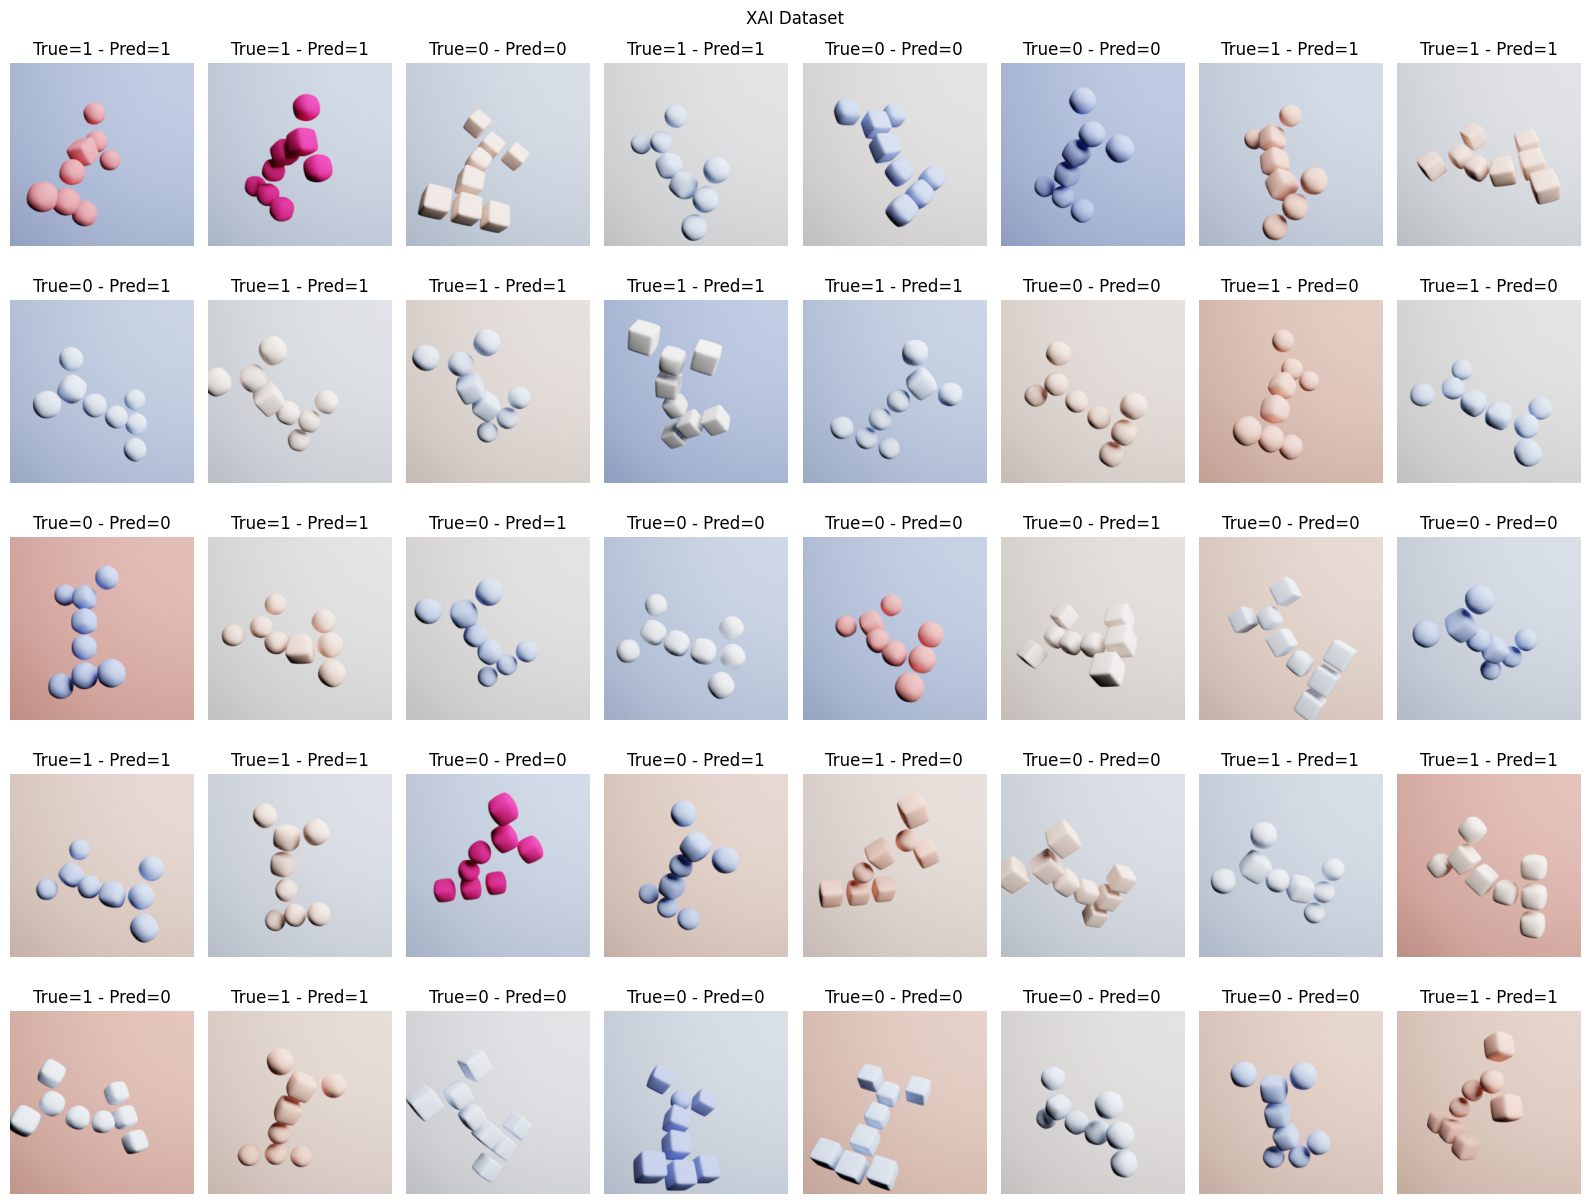

In [21]:
display_images(study_df, 5, 8, main_dir, f'XAI Dataset', random_state=0)

## Generate Examples

In [22]:
# CSV Generation

import random
import ast
import numpy as np
import pandas as pd
import csv

# Class labels
CLASSES = ['Healthy', 'OCDegen']


def get_xray_trait(df, xray_filename):
    matches = df.loc[
        df['filename'] == xray_filename,
        'ill_chars'
    ].values
    if len(matches) == 0:
        return "Unknown"
    ill_raw = matches[0]
    try:
        traits = ast.literal_eval(ill_raw) if isinstance(ill_raw, str) else ill_raw
    except:
        traits = []

    mapped = []
    for trait in traits:
        t = trait.strip()
        if "mutation_color" in t.lower():
            continue
        if t in ["high_bend", "med_bend"] and "Strong Spine Bend" not in mapped:
            mapped.append("Strong Spine Bend")
        elif t in ["high_sphere_diff", "med_sphere_diff"] and "Strong Bone Variation" not in mapped:
            mapped.append("Strong Bone Variation")
        elif t == "mutation_mainbones" and "Main Bones Mutation" not in mapped:
            mapped.append("Main Bones Mutation")
        elif t == "stretchy" and "Tucked Head" not in mapped:
            mapped.append("Tucked Head")
        else:
            mapped.append(t)
    return ", ".join(mapped) if mapped else "No Trait"


# Final schema
final_columns = [
    "INDEX", "PATIENT_ID", "X_RAY_IMAGE", "X_RAY_TRAIT",
    "TRUE_DIAG", "SUGGESTED_DIAG",
    "X_RAY_LOCATION"
]

# Start with an empty DataFrame
df = pd.DataFrame(columns=final_columns)

# Build one row per X-ray
for _, row in study_df.iterrows():
    target_true     = int(row['ill'])
    target_pred     = int(row['pred'])
    id_to_drop      = row['id']


    new_row = {
        "PATIENT_ID": row['p_id'],
        "X_RAY_IMAGE": row['filename'],
        "TRUE_DIAG": CLASSES[target_true],
        "SUGGESTED_DIAG": CLASSES[target_pred],
    }
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

df['X_RAY_TRAIT']      = df['X_RAY_IMAGE'].apply(lambda x: get_xray_trait(study_df, x))

# Random locations
locations = ["DEN", "SEA", "CHI", "SF", "MIA", "PHX", "BOS", "ATL"]
df["X_RAY_LOCATION"] = random.choices(locations, k=len(df))

# Refresh INDEX
if "INDEX" in df.columns:
    df = df.drop(columns=["INDEX"])
df["INDEX"] = random.sample(range(1, 100 + len(df)), len(df))

# Reorder & save with quoting so newlines persist
df = df[final_columns]
df.to_csv(
    output_folder / "main_data/input_example.csv",
    index=False,
    quoting=csv.QUOTE_ALL
)
print(f"Saved {output_folder / 'main_data/input_example.csv'} with multiline captions")

Saved output/xai_samples/no_xai/main_data/input_example.csv with multiline captions


In [23]:
df

,INDEX,PATIENT_ID,X_RAY_IMAGE,X_RAY_TRAIT,TRUE_DIAG,SUGGESTED_DIAG,X_RAY_LOCATION
0,99,V7D26RWP,2723232d-db8a-41a4-8c02-498dcb88baa6.png,"Strong Spine Bend, Strong Bone Variation, Tuck...",OCDegen,OCDegen,DEN
1,2,URPAJZ2S,449e62be-4733-44b6-bcc4-1243ebb15bba.png,"Tucked Head, Strong Spine Bend",OCDegen,OCDegen,PHX
2,120,81Z7S9HS,d59bf4e5-b1e8-48fb-8b8a-c73bc831a150.png,Tucked Head,Healthy,Healthy,SF
3,69,N9YHVWQW,c8f0e96e-e697-47f8-b67a-2e1b54d5be19.png,"Strong Spine Bend, Main Bones Mutation",OCDegen,OCDegen,ATL
4,31,ML8JDXLY,be597e26-d153-49c5-a05a-2541ff0b02ba.png,No Trait,Healthy,Healthy,BOS
5,25,FJ5Y9G16,a8b35c43-d857-47ca-8ebf-c33fcab65f95.png,Tucked Head,Healthy,Healthy,SF
6,7,0TTYM3HS,b3458f5b-9f17-4186-90ca-57e8bf1bc739.png,"Strong Bone Variation, Main Bones Mutation",OCDegen,OCDegen,CHI
7,131,DJB2A4UL,d2fa9641-b965-411e-8256-95e8533a017e.png,"Tucked Head, Strong Spine Bend",OCDegen,OCDegen,MIA
8,110,X5ODJ200,039e360f-fe43-4e2a-9d17-a0a1634ddb7d.png,Main Bones Mutation,Healthy,OCDegen,BOS
9,6,6QFEBW22,58567d1a-14c6-4d82-aafa-16c362d827e1.png,"Strong Bone Variation, Tucked Head",OCDegen,OCDegen,PHX


In [24]:
#Zipfile

example_dr = ds_dir / 'test'  # Added definition for example_dr
zip_filename = output_folder / "main_data/study_images_example.zip"

# 'X_RAY_IMAGE', 
example_files = []

main_filecol = ['X_RAY_IMAGE']
main_files = pd.unique(df[main_filecol].values.ravel())

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for img_name in example_files:
        img_path = example_dr / img_name
        if img_path.exists():
            zipf.write(img_path, arcname=img_name)

    for img_name in main_files:
        img_path = main_dir / img_name
        if img_path.exists():
            zipf.write(img_path, arcname=img_name)

print(f"Saved {len(example_files) + len(main_files)} images to {zip_filename}")

Saved 40 images to output/xai_samples/no_xai/main_data/study_images_example.zip


## Tutorial Data

In [25]:
# Start with an empty DataFrame
df = pd.DataFrame(columns=final_columns)

# Build one row per X-ray
for _, row in tutorial_df.iterrows():
    target_true     = int(row['ill'])
    target_pred     = int(row['pred'])
    id_to_drop      = row['id']


    new_row = {
        "PATIENT_ID": row['p_id'],
        "X_RAY_IMAGE": row['filename'],
        "TRUE_DIAG": CLASSES[target_true],
        "SUGGESTED_DIAG": CLASSES[target_pred],
    }
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

df['X_RAY_TRAIT']      = df['X_RAY_IMAGE'].apply(lambda x: get_xray_trait(tutorial_df, x))

# Random locations
locations = ["DEN", "SEA", "CHI", "SF", "MIA", "PHX", "BOS", "ATL"]
df["X_RAY_LOCATION"] = random.choices(locations, k=len(df))

# Refresh INDEX
if "INDEX" in df.columns:
    df = df.drop(columns=["INDEX"])
df["INDEX"] = random.sample(range(1, 100 + len(df)), len(df))

# Reorder & save with quoting so newlines persist
df = df[final_columns]
df.to_csv(
    output_folder / "tutorial_data/input_example.csv",
    index=False,
    quoting=csv.QUOTE_ALL
)
print(f"Saved {output_folder / 'tutorial_data/input_example.csv'} with multiline captions")

Saved output/xai_samples/no_xai/tutorial_data/input_example.csv with multiline captions


In [26]:
df

,INDEX,PATIENT_ID,X_RAY_IMAGE,X_RAY_TRAIT,TRUE_DIAG,SUGGESTED_DIAG,X_RAY_LOCATION
0,80,JNF4BF8Z,3e7da57f-bc60-4f3d-a374-872088e3795e.png,Main Bones Mutation,Healthy,Healthy,ATL
1,61,JJVEOS67,56591a49-6a14-4b02-8c82-37db171334e2.png,"Strong Bone Variation, Main Bones Mutation",OCDegen,OCDegen,CHI
2,75,ZHY0V812,365a071e-2af3-42ca-ad1f-bf68c306fb99.png,No Trait,Healthy,Healthy,SEA
3,70,QNT04OW2,b03b85f7-b156-46b8-aa7e-94684086179a.png,"Main Bones Mutation, Tucked Head",OCDegen,OCDegen,CHI
4,56,A7T6L95X,1a51763c-6e4c-4c2f-b4d1-f7bec68df62a.png,Main Bones Mutation,Healthy,Healthy,SEA
5,106,XNYTPNXB,e06a4ede-6922-4266-a9f9-dadb4f48b378.png,No Trait,Healthy,Healthy,CHI
6,97,90VJ59VI,46051ae3-355e-4886-b689-cdba61701791.png,"Strong Bone Variation, Tucked Head, Strong Spi...",OCDegen,OCDegen,DEN
7,113,ZHCW6F6Z,5877df96-5ac7-42d4-add6-e730655680b7.png,"Main Bones Mutation, Strong Bone Variation",OCDegen,Healthy,MIA
8,66,6RJE2Y5A,7a6c4a43-74df-4d3a-b008-194d2a0d3a01.png,"Tucked Head, Strong Spine Bend",OCDegen,Healthy,CHI
9,101,X6GIKPV0,8f27be44-3eba-4eb3-a6b2-de85f50916da.png,Strong Bone Variation,Healthy,OCDegen,SF


In [27]:
#Zipfile

example_dr = ds_dir / 'test'  # Added definition for example_dr
zip_filename = output_folder / "tutorial_data/study_images_example.zip"

# 'X_RAY_IMAGE', 
example_files = []

main_filecol = ['X_RAY_IMAGE']
main_files = pd.unique(df[main_filecol].values.ravel())

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for img_name in example_files:
        img_path = example_dr / img_name
        if img_path.exists():
            zipf.write(img_path, arcname=img_name)

    for img_name in main_files:
        img_path = tutorial_dir / img_name
        if img_path.exists():
            zipf.write(img_path, arcname=img_name)

print(f"Saved {len(example_files) + len(main_files)} images to {zip_filename}")

Saved 20 images to output/xai_samples/no_xai/tutorial_data/study_images_example.zip
